# İlk Tekrarlayan Sinir Ağınız (RNN)

🙌 RNN'lere hoş geldiniz! Önceki derste görseller (uzamsal veri) ile ilgilenmek için CNN'leri kullandıktan sonra, şimdi zamanla ilgili veriler (***zamansal veri***) ile ilgileneceksiniz.

🎯 Bu ısınma challenge'ının hedefleri:

1. Zamansal verinin ne olduğunu anlamak
2. İlk Tekrarlayan Sinir Ağlarınızı oluşturmak



_Not: Google Colab kullanmaya gerek yok ❌_

## (1) 📚 Veri seti

_Uyarı: bu bölümde kendiniz kod yazmanıza gerek yok, dikkatli okuyun ve hücreleri çalıştırın. RNN ve LSTM modellerine odaklanmanızı istiyoruz, Python sorularına değil_ 😉

🔢 Bir şirketteki çalışanlar hakkında bazı verilere erişimimiz olduğunu düşünün.

In [1]:
import numpy as np

X = np.load('X.npy')
y = np.load('y.npy')

In [2]:
X.shape, y.shape

((25000, 10, 3), (25000,))

☝️ Veri seti **25.000 çalışanın istihdam durumunun yıllar içindeki gelişimini** tanımlar: her sekans 10 ardışık yıla karşılık gelir ve her yıl 3 bileşenden oluşan bir iş durumunu açıklar
- maaş,
- sorumluluğundaki kişi sayısı,
- şirketin büyüklüğü.

🕵🏻 Veri setini biraz daha iyi anlamak için ilk çalışanın verilerine bakalım.

In [3]:
import pandas as pd

employee_0 = pd.DataFrame(X[0],
                          columns=['salary',
                                   'responsibility',
                                   'company_size'])
round(employee_0,2)

,salary,responsibility,company_size
0,0.80,10.73,102.0
1,0.50,10.73,102.0
2,0.60,10.73,102.0
3,0.71,10.73,130.0
4,0.94,10.73,130.0
5,1.05,10.73,130.0
6,1.12,32.00,108.0
7,4.87,32.00,108.0
8,4.97,33.00,108.0
9,5.20,39.00,108.0


🎯 Bu challenge'ın amacı, geçmiş gözlemlere dayanarak bu 25.000 çalışanın her biri için 11. yıldaki aylık maaşı tahmin etmektir.

In [4]:
# For example, the first employee earns 6.499 k USD per month
# during the 11th year at the company
y[0]

6.499

📈 Maaşların, sorumluluklarındaki kişi sayısının ve şirket büyüklüğünün yıllar içindeki gelişimini daha iyi anlamanız için aşağıdaki hücreyi çalıştırabilirsiniz. Bu üç değişken arasında görsel olarak bazı korelasyonlar tespit edebiliyor musunuz?

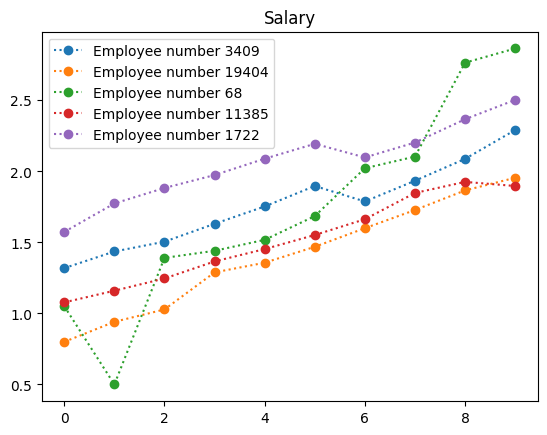

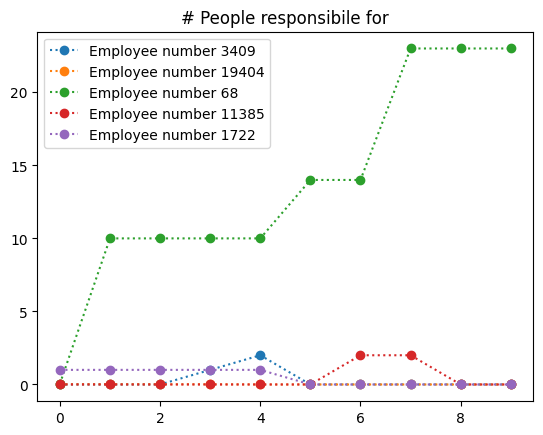

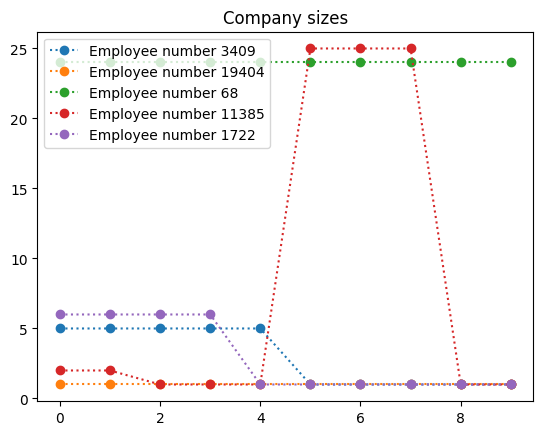

In [5]:
import matplotlib.pyplot as plt
%matplotlib inline

number_of_employees = len(X)

### Choosing random employees
##### As the employees are selected randomly, feel free to re-run this cell a few times !

number_of_randomly_selected_employees = 5

random_selection = np.random.randint(0,
                                     number_of_employees,
                                     number_of_randomly_selected_employees)


### Plotting data for the selected employees

plt.title('Salary')
for r in random_selection:
    plt.plot(X[r, :, 0],label=f"Employee number {r}",linestyle=":",marker="o")
    plt.legend(loc='upper left')
plt.show()

plt.title('# People responsibile for')
for r in random_selection:
    plt.plot(X[r, :, 1],label=f"Employee number {r}",linestyle=":",marker="o")
    plt.legend(loc='upper left')
plt.show()

plt.title('Company sizes')
for r in random_selection:
    plt.plot(X[r, :, 2],label=f"Employee number {r}",linestyle=":",marker="o")
    plt.legend(loc='upper left')
plt.show()

🕵🏻 **Veri Keşfi** 🕵🏻 Gözlemlerin değişkenliğini daha iyi anlamak için şunların dağılımına bakın:
* 10. yıldaki tüm maaşlar,
* sorumluluğundaki kişiler,
* ve şirket büyüklükleri

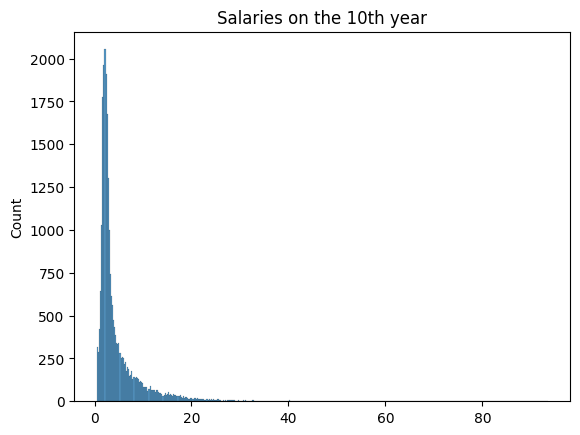

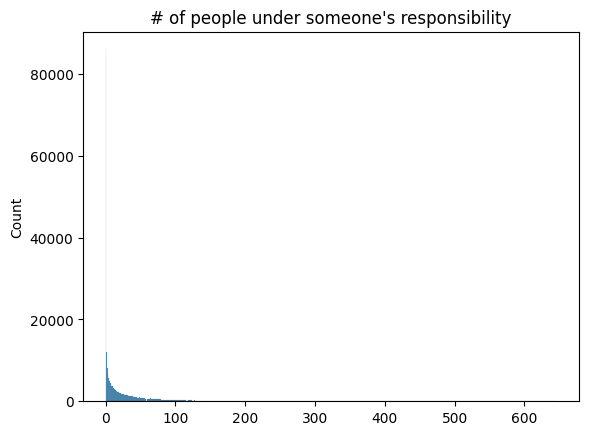

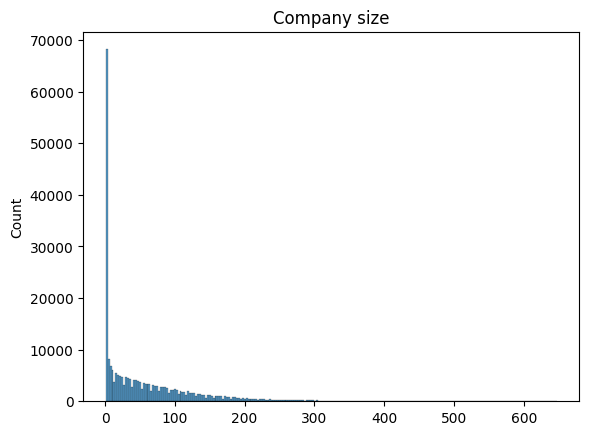

In [6]:
import seaborn as sns

plt.title("Salaries on the 10th year")
sns.histplot(X[:, -1, 0].flatten()) # all the employees, last year, feature #0 = salaries
plt.show()

plt.title("# of people under someone's responsibility")
sns.histplot(X[:, :, 1].flatten()) # all the employees, all the years, feature #1 = responsabilities
plt.show()

plt.title("Company size")
sns.histplot(X[:, :, 2].flatten()) # all the employees, all the years, feature #2 = company size
plt.show()

✂️ **Tutma yöntemi** Veri setini eğitim ve test setine ayıralım (80/20)

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20)

# Notice that we are train_test_splitting the 25 000 employees!

## (2) 💻 Basit bir RNN

🤗 Artık bu şirketin veri setiyle tanıştığınıza göre, ilk Tekrarlayan Sinir Ağınızı oluşturacaksınız. Basit bir mimariyle başlayalım.

❓ **Soru** ❓ Şunları içeren bir model yazın:
- Eğitim setine uyarlanmış bir ***Normalization*** katmanı
- 20 *ünite* içeren bir ***SimpleRNN*** katmanı (Tekrarlayan Katman için aktivasyon fonksiyonu olarak `tanh`'ın daha uygun olduğunu unutmayın)
- 10 nöronlu bir ***Dense*** katmanı
- Görevinize özel bir ***Dense*** katmanı (= maaş ***tahmini*** yapmak için)

👩🏻‍🏫 Unutmayın: İlk katmandan önce `keras.Input` eklemeyi unutmayın.

In [8]:
from keras import Sequential, Input
from keras.layers import Dense, SimpleRNN, Flatten, Normalization

2026-05-14 22:06:43.929732: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-14 22:06:43.931845: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-14 22:06:43.942527: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-14 22:06:43.960169: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-14 22:06:43.983076: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registe

In [10]:
normalizer = Normalization()

# Model
model = Sequential([
    Input(shape=(10, 3)),
    normalizer,
    SimpleRNN(20, activation="tanh"),
    Dense(10, activation="relu"),
    Dense(1)
])

normalizer.adapt(X_train)



2026-05-14 22:07:02.768154: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-14 22:07:02.771359: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2251] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


❓ **Soru**: RNN'inizde kaç tane eğitilebilir parametre var ❓

In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (None, 10, 3)          │             7 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 20)             │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │           210 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 708 (2.77 KB)

 Trainable params: 701 (2.74 KB)

 Non-trainable params: 7 (32.00 B)

❓ **Soru** ❓ Parametre sayısını elle yeniden hesaplamaya çalışın.


(3 + 20 + 1) × 20 = 22 × 20 = 480   (SimpleRNN)
(20 + 1) × 10 = 210    (Dense10)
(10 + 1) × 1 = 11  (Dense1)
3 (non-trainable - normalization)

<details>
    <summary><i>Cevap</i></summary>


- <u> Normalizasyon Katmanı</u>: 
    - Bu katman normalize edilecek $\color{red}{n_x = 3} $ özelliğe (maaş, sorumluluk, şirket büyüklüğü) sahiptir. Her biri için <font color=blue>_ortalama_</font> ve <font color=blue>_standart_sapma_</font> hesaplanması gerekir. Yani $\color{red}{n_x = 3} \times \color{blue}{2} = 6$ eğitilemez parametremiz vardır. 7. parametre başlangıçta 0'a ayarlanmış bir bias'tır.

- <u> Tekrarlayan Katman</u>: 
    - Eğer $\color{green}{n_h = 20} $ RNN ünitesi $\color{red}{n_x = 3} $ özelliğe paralel uygulanırsa, Tekrarlayan Katman $\color{green}{n_h}(\color{green}{n_h} + \color{red}{n_x} + 1) = \color{green}{20} \times (\color{green}{20}+\color{red}{3}+1) = \color{green}{20} \times 24 = 480$ eğitilebilir parametreye sahiptir.
    - Bu sayının her sekansın uzunluğundan (burada 10 gün) *bağımsız* olduğuna dikkat edin
    
- <u> Yoğun Katman</u>: 
    - $\color{green}{n_h = 20} $ RNN ünitesi ve $1$ bias ile başlayarak, 10 nöron kullanarak, Yoğun Katman $ (\color{green}{20}+1) \times 10 = 21 \times 10 = 210$ parametreye sahiptir
    
- <u> Tahmin Yoğun Katmanı</u>: 
    - $10$ nöron ve $1$ bias ile başlayarak, 11. maaşı tahmin etmek için 1 nöron kullanarak, Tahmin Yoğun Katmanı $ (10+1) \times 1 = 11 \times 1 = 11$ parametreye sahiptir
    
</details>    

❓ **Soru** ❓ Modelinizi derleyin. RNN için ***rmsprop*** optimizer'ını (*adam* yerine) kullanmanızı öneriyoruz.

In [12]:
model.compile(
    optimizer="rmsprop",
    loss="mse"
)

❓ **Sorular** ❓ 

* Modelinizi eğitim veri setinizde eğitin:
    * %20'lik bir Doğrulama Bölümü kullanın
    * ve sabır $= 5 $ olan bir Erken Durdurma Kriteri kullanın
* Test setindeki performansınızı değerlendirin

In [13]:
from keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=200,
    callbacks=[early_stopping],
    verbose=1
)

test_loss = model.evaluate(X_test, y_test, verbose=0)
print("Test Loss (MSE):", test_loss)

Epoch 1/200
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 19.1774 - val_loss: 7.5643
Epoch 2/200
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 3.1319 - val_loss: 2.7883
Epoch 3/200
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.4933 - val_loss: 1.6500
Epoch 4/200
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1.1118 - val_loss: 1.2458
Epoch 5/200
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.9665 - val_loss: 1.0891
Epoch 6/200
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.8741 - val_loss: 0.9399
Epoch 7/200
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.8163 - val_loss: 0.8847
Epoch 8/200
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.7886 - val_loss: 0.7897
Epoch 9/200
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.7360 - val_loss: 0.8416
Epoch 10/200
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.7221 - val_loss: 0.7782
Epoch 11/200
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6974 - val_loss: 0.6966
Epoch 12/200
500/500 ━━━━━━━━━━━━━━━━━━━

## (3) 💻 Temel karşılaştırma

> ❗️ **Önemli hatırlatma** ❗️ 
>  
> ***Derin Öğrenme modellerinizi ve daha genel olarak herhangi bir Makine Öğrenmesi modelini her zaman bir temel modelle karşılaştırmayı unutmayın.***

🧑🏻‍🏫 Amacımızın çalışanların 11. yıl için maaşını tahmin etmek olduğunu unutmayın. Bu bir ***Regresyon görevidir***. Hangi temel modeli oluşturabiliriz?
1. Geleneksel regresyon modeli durumunda, `y_test` için temel tahmin **`y_train`'in ortalamasını tahmin etmektir**... ancak bu seçenek zamanla ilgili seriler için alakasız olabilir. Teorik olarak, birinin maaşının yıllar içinde artması gerekir!
2. Regresyon görevi için alternatif temel tahmin **son görülen değeri tahmin etmektir**

❓ **Sorular** ❓ 
* 10. ve 11. yıl arasında maaşın sabit kaldığını tahmin eden temel modelin Ortalama Mutlak Hatasını hesaplayın
* Bu temel modeli RNN'inizle karşılaştırın

In [14]:
y_pred_baseline = X_test[:, -1, 0]
from sklearn.metrics import mean_absolute_error

baseline_mae = mean_absolute_error(y_test, y_pred_baseline)

print("Baseline MAE:", baseline_mae)

Baseline MAE: 0.6103756006417274


In [18]:
y_pred_rnn = model.predict(X_test)
rnn_mae = mean_absolute_error(y_test, y_pred_rnn)

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


👉 Bu soruda takılırsanız, `(4) LSTM`'i deneyin ve sonra buraya geri dönün.

🧑🏻‍🏫 Gerekirse TA'ya sorun. Cevaba sadece bu soruları başarısızlıkla cevaplamaya çalıştıktan sonra bakın.

<details>
    <summary><i>Cevap</i></summary>


```python
# Bir sonraki maaşı tahmin etmek için X'teki son maaşı kullanma
y_test_baseline = X_test[:, -1, 0] 
mae_baseline = np.mean(np.abs(y_test - y_test_baseline))   
```
    
</details>    

😁 RNN'inizin temel modelden biraz daha iyi performans gösterdiğini fark etmelisiniz.

## (4) 💻 LSTM: Uzun-Kısa Süreli Bellek

❓ **Sorular** ❓ 

* Aynı modeli yazın, ancak `SimpleRNN` katmanı yerine `LSTM` katmanı ile
* Test setindeki performansınızı değerlendirin

In [15]:
from keras import Sequential, Input
from keras.layers import Dense, LSTM, Normalization

normalizer = Normalization()

model = Sequential([
    Input(shape=(10, 3)), 
    normalizer,
    LSTM(20),               
    Dense(10, activation="relu"),
    Dense(1)
])

In [16]:
model.compile(
    optimizer="rmsprop",
    loss="mse",
    metrics=["mae"]
)

In [17]:
from keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=200,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/200
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 20.7396 - mae: 2.0363 - val_loss: 9.0553 - val_mae: 1.0593
Epoch 2/200
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 4.4632 - mae: 0.8253 - val_loss: 4.0118 - val_mae: 0.6798
Epoch 3/200
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 2.7499 - mae: 0.6782 - val_loss: 3.1336 - val_mae: 0.7318
Epoch 4/200
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 2.2087 - mae: 0.6246 - val_loss: 2.1427 - val_mae: 0.5627
Epoch 5/200
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1.9109 - mae: 0.6046 - val_loss: 1.9301 - val_mae: 0.5123
Epoch 6/200
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1.7570 - mae: 0.5776 - val_loss: 1.9506 - val_mae: 0.6587
Epoch 7/200
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1.6590 - mae: 0.5695 - val_loss: 1.4625 - val_mae: 0.4717
Epoch 8/200
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1.5441 - mae: 0.5533 - val_loss: 1.6930 - val_mae: 0.4768
Epoch 9/200
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms

In [18]:
test_loss, test_mae = model.evaluate(X_test, y_test, verbose=0)

print("Test Loss (MSE):", test_loss)
print("Test MAE:", test_mae)

Test Loss (MSE): 1.39504873752594
Test MAE: 0.5052308440208435


💪 LSTM, daha düşük MAE ile SimpleRNN'den biraz daha iyi performans göstermelidir.

🏁 Tebrikler! Sıralı veriler üzerinde RNN eğitmeyi öğrendiniz.
 

💾 Notebook'unuzu git add/commit/push yapmayı unutmayın...

🚀 ... ve sonraki challenge'a geçin!

---

<u>Not</u>: Üzerinde çalıştığınız sekanslar tamamen sahte. Benzer verileri eğitmeniz ve üretmeniz gerektiğinde, böyle bir veri setini simüle etmek için kullanılan fonksiyonları aşağıda bulabilirsiniz.

## 🛠 (Yardımcı Araçlar)

In [19]:
def create_sequences(number):
    X, y = [], []

    for i in range(number):
        x_i, y_i = create_individual_sequence(10)
        X.append(x_i)
        y.append(y_i)

    return np.array(X), np.array(y)

def create_individual_sequence(length):
    company_sizes = []
    nb_persons = []
    salaries = []


    # Education level
    educ_level = [max(0, int(np.random.normal(10, 2)))]*length

    # Company size
    current_size = int(1 + np.random.beta(.4, 4)*500)
    for i in range(length):
        if not np.random.randint(4): # Change 1 out of 3 possibilities
            current_size = int(max(1, np.random.normal(current_size, 50)))
        company_sizes.append(current_size)

    # Number of persons
    nb_iter = np.random.beta(.15, 4)*300
    for i in range(length):
        if not np.random.randint(2): # Change 1 out of 2 possibilities
            R_1 = np.random.beta(0.5, 8)*3
            nb_iter = nb_iter + max(-2, R_1*company_sizes[i] + np.random.randint(-2, 2))
            nb_iter = max(0, nb_iter)
            nb_iter = int(min(company_sizes[i]-1, nb_iter))
        nb_persons.append(nb_iter)


    # Salary
    salary_iter = max(800, int(np.random.normal(1200, 300)+ 0.05*company_sizes[0] +  np.random.normal(40, 400)))
    salaries.append(salary_iter)
    for i in range(1, length + 1):
        R_1 = np.random.normal(100, 50)
        change_person = nb_persons[i-1] - nb_persons[i-2]
        change_company = max(0, company_sizes[i-1] - company_sizes[i-2])
        salary_iter = salary_iter + 0.05*change_company + change_person*R_1 + np.random.normal(100, 50)
        salary_iter = max(int(salary_iter), 500)

        salaries.append(salary_iter)

    y = salaries[-1]/1000
    salaries = [_/1000 for _ in salaries[:-1]]

    return np.array([salaries, nb_persons, company_sizes]).T, y

In [ ]:
#X, y = create_sequences(25000)

#np.save('X', X.astype(np.float32))
#np.save('y', y)